# Compare results to NASA NEX-GDDP

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import fsspec
from tqdm.notebook import tqdm
import re
import os
import glob
import string

from distributed import Client
import warnings

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from cartopy import crs as ccrs
import cmocean

from funcs_support import get_filepaths, get_params, utility_save, area_mean, utility_print

dir_list = get_params()

In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=True)


In [5]:
# Start dask client
client = Client()
display(client)

/glade/u/home/schwarzwald/.conda/envs/bcd_me/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37653 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/37653/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/37653/status,Workers: 2
Total threads: 2,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44943,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/37653/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33545,Total threads: 1
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/46779/status,Memory: 5.00 GiB
Nanny: tcp://127.0.0.1:40951,


## Download NEX-GDDP

In [4]:
#----------- Processing Models -----------
# Get GWL info
gwl_info = _load_gwls()

params_var = {'var':'tas','freq':'day'}
# Get model filepath info
df = get_filepaths()
df = df.query('varname == "'+params_var['var']+'" and '+
              'freq == "'+params_var['freq']+'"')
# Get global files (no suffix)
df = df.where(df.suffix != df.suffix).dropna(how='all')

keys_all = [k for k in gwl_info.groupby(['model','ensemble','exp']).groups]
keys_all = [k for k in keys_all if k in df.groupby(['model','run','exp']).groups]

# Subset to just files that have both historical and future data 
# (saved under the future experiment name, not 'historical') 
keys_all = [k for k in keys_all if k[2] != 'historical']


dest_dir = '/glade/derecho/scratch/schwarzwald/nex-gddp_staging/'
gwls = [1.5,2,3]


In [6]:
keys_all = [k for k in keys_all if k[1] == 'r1i1p1f1']

In [6]:
verbose_skips = False
for keys in tqdm(keys_all[1:None]):
    for gwl in gwls:
        if len(glob.glob(f"{dest_dir}{params_var['var']}_{params_var['freq']}_{keys[0]}_{keys[2]}_{keys[1]}_*_GWL{str(gwl)}.zarr")) == 0:
            try:
                # Get years for GWL2 for this model, ensemble member, experiment
                year_list = gwl_info.reset_index().set_index(['model','ensemble','exp','warming_level']).loc[(*keys,gwl)]
            except:
                if verbose_skips:
                    print('No GWL info for '+str(keys)+', '+str(gwl)+', skipped.')
                continue
            year_list = np.arange(year_list['start_year'],
                      year_list['end_year']+1)
        
            # Download files from AWS bucket
        
            # Get access to AWS bucket
            source_dir = f"/nex-gddp-cmip6/NEX-GDDP-CMIP6/{keys[0]}/{keys[2]}/{keys[1]}/{params_var['var']}/"
            if not s3.exists(source_dir):
                if verbose_skips:
                    print(source_dir+' not found, skipped.')
                continue
            source_fns = s3.ls(source_dir)
            # (choosing the last one, alphabetically, for each year, which gets
            # the most recent version, i.e., _v2.0.nc)
            try:
                source_fns = [[fn for fn in source_fns if re.search(r'\_'+str(yr),fn)][-1] for yr in year_list]
            except:
                if verbose_skips:
                    print('Not all of '+', '.join([str(y) for y in year_list])+' found in '+source_dir+', skipped.')
                continue
        
            for source_fn in source_fns:
                os.system(f'aws s3 cp s3://{source_fn} {dest_dir}')
        
            # Get list of downloaded files
            fns = glob.glob(f"/glade/derecho/scratch/schwarzwald/nex-gddp_staging/{params_var['var']}_{params_var['freq']}_{keys[0]}_{keys[2]}_{keys[1]}_*.nc")
            fns = np.sort(fns)
        
            # Load downloaded files
            dss = xr.open_mfdataset(fns)
            # Rechunk to make regional processing easier
            dss = dss.chunk({'lat':50,'lon':50,'time':-1})
        
            # Get new output file
            datestr = (re.sub(r'\-','',str(dss.time.min().values)[0:10])+'-'+
                       re.sub(r'\-','',str(dss.time.max().values)[0:10]))
            output_fn = (f"{dest_dir}{params_var['var']}_{params_var['freq']}_{keys[0]}_{keys[2]}_{keys[1]}_{datestr}_GWL{str(gwl)}.zarr")
            
            dss.attrs = {'DESCRIPTION':'NASA NEX-GDDP, subset to GWL2, from AWS bucket',
                         'SOURCE':'comparison_to_nexgddp.ipynb'}
        
            # Output
            utility_save(dss,output_fn,zarr_mode='w',save_kwargs = {'zarr_format':3,'consolidated':False})
            
            # Remove raw netcdf files
            for fn in fns:
                os.system('rm -rf '+fn)
        else:
            print(', '.join(keys)+' processed already, skipped.')

  0%|          | 0/28 [00:00<?, ?it/s]

ACCESS-ESM1-5, r1i1p1f1, ssp585 processed already, skipped.
ACCESS-ESM1-5, r1i1p1f1, ssp585 processed already, skipped.
ACCESS-ESM1-5, r1i1p1f1, ssp585 processed already, skipped.
CanESM5, r1i1p1f1, ssp245 processed already, skipped.
CanESM5, r1i1p1f1, ssp245 processed already, skipped.
CanESM5, r1i1p1f1, ssp370 processed already, skipped.
CanESM5, r1i1p1f1, ssp585 processed already, skipped.
EC-Earth3, r1i1p1f1, ssp245 processed already, skipped.
EC-Earth3, r1i1p1f1, ssp370 processed already, skipped.
EC-Earth3, r1i1p1f1, ssp370 processed already, skipped.
EC-Earth3, r1i1p1f1, ssp585 processed already, skipped.
EC-Earth3, r1i1p1f1, ssp585 processed already, skipped.
EC-Earth3, r1i1p1f1, ssp585 processed already, skipped.
IPSL-CM6A-LR, r1i1p1f1, ssp245 processed already, skipped.
IPSL-CM6A-LR, r1i1p1f1, ssp245 processed already, skipped.
IPSL-CM6A-LR, r1i1p1f1, ssp370 processed already, skipped.
IPSL-CM6A-LR, r1i1p1f1, ssp370 processed already, skipped.
IPSL-CM6A-LR, r1i1p1f1, ssp585 p

## Compare to BCD-ME

In [7]:
nex_fns = np.sort(glob.glob(f'{dest_dir}{params_var['var']}_{params_var['freq']}*.zarr'))
nex_fns = {mod:[fn for fn in nex_fns if mod in fn] for mod in 
           np.unique([re.split(r'\_',re.split(r'\/',fn)[-1])[2] for fn in nex_fns])}

In [11]:
output_fn = f'{dir_list['aux_bigmem']}validation/means_bcd_nex.zarr'

if os.path.exists(output_fn):
    means = xr.open_zarr(output_fn)
else:
    
    means_bcd = {}
    means_nex = {}
    
    for mod in tqdm(nex_fns,total=len(nex_fns)):
    #for mod in ['ACCESS-ESM1-5']:
        # Load NEX-GDDP files for a given model and preprocess them into 
        # same format as BCD-ME
        with warnings.catch_warnings():
            # Ignores .done file warning and chunk number increase warning
            warnings.filterwarnings('ignore') 
        
            dss_nex = [(xr.open_zarr(fn,consolidated=False).
              expand_dims({'experiment':[re.split(r'\_',re.split(r'\/',fn)[-1])[3]],
                           'run':[re.split(r'\_',re.split(r'\/',fn)[-1])[4]],
                           'proj_base':['GMFD'],
                           'gwl':[float(re.search(r'L.*\.',re.search(r'\_GWL[(0-9)\-].*\.',fn).group()).group()[1:-1])]}))
             for fn in nex_fns[mod]]
            
            for idx in range(len(dss_nex)):
                dss_nex[idx] = dss_nex[idx].assign_coords({'year':dss_nex[idx].time.dt.year,
                                                         'dayofyear':dss_nex[idx].time.dt.dayofyear})
                
                dss_nex[idx] = dss_nex[idx].set_index(time=['dayofyear','year']).unstack()
            
                dss_nex[idx]['year'] = np.arange(1,dss_nex[idx].sizes['year']+1)
            
                dss_nex[idx] = dss_nex[idx].sel(dayofyear=slice(1,365))
        
                dss_nex[idx] = dss_nex[idx].stack(idv = ['experiment','run'])
            
            dss_nex = xr.combine_by_coords(dss_nex,combine_attrs='drop',join='outer')
            # Change to -180:180 longitude
            dss_nex = xa.fix_ds(dss_nex)
    
        # Load corresponding BCD-ME file 
        dss_bcd = xr.open_zarr(f'/glade/campaign/cgd/cas/schwarzwald/bcd_me/bcd_me_qdm-qplad_{mod}.zarr',decode_timedelta=False)
        dss_bcd = dss_bcd.set_index(idv = ['experiment','run'])
        # Subset to same runs / expeirments / gwls / proj_base (GMFD) 
        # as the NEX-GDDP 
        dss_bcd = dss_bcd.sel(idv = dss_nex.idv.values,
                    gwl = dss_nex.gwl.values,
                    proj_base = dss_nex.proj_base.values)
    
        # Subset NEX to same lats as BCD-ME
        dss_nex = dss_nex.sel(lat=dss_bcd.lat.values)
        
        # Remove proj_base dimensions for convenience
        dss_nex = dss_nex.isel(proj_base=0,drop=True)
        dss_bcd = dss_bcd.isel(proj_base=0,drop=True)
    
        # Get 20-year mean T of BCD-ME
        mean_bcd = (dss_bcd['tassumpoly'].sel(degree=1)/365).compute().to_dataset(name='tasmean').drop_vars('degree',errors='ignore')
        
        # Get 20-year mean T of NEX
        mean_nex = dss_nex.mean(['dayofyear','year']).compute()
        # Change to dataarray in C instead of K to match BCD-ME above
        mean_nex = (mean_nex.tas-273.15).to_dataset(name='tasmean')
    
        # Get change in means for each model  
        means_bcd[mod] = mean_bcd#(mean_bcd - mean_bcd.sel(gwl=1.5)).sel(gwl = [g for g in mean_bcd.gwl.values if g != 1.5])
        means_nex[mod] = mean_nex#(mean_nex - mean_nex.sel(gwl=1.5)).sel(gwl = [g for g in mean_nex.gwl.values if g != 1.5])
    
    # Concat into single file
    means_bcd = xr.concat([ds.expand_dims({'model':[mod]}).unstack().stack(idv = ['model','experiment','run']) for mod,ds in means_bcd.items()],
              dim='idv',join='outer')
    means_nex = xr.concat([ds.expand_dims({'model':[mod]}).unstack().stack(idv = ['model','experiment','run']) for mod,ds in means_nex.items()],
              dim='idv',join='outer')
    means = xr.concat([means_bcd,means_nex],
                      dim=pd.Index(['bcd-me','nex-gddp'],name='source'))
    
    # Export
    means.attrs = {'SOURCE':'comparison_to_nexgddp.ipynb',
                   'DESCRIPTION':'means (across time) at each location of equivalent periods in BCD-ME and NASA NEX-GDDP, by GWL'}
    utility_save(means.reset_index('idv'),output_fn,zarr_mode = 'w')

In [12]:
mean_diff = means.sel(gwl=3) - means.sel(gwl=1.5)
keep_idxs = (~np.isnan(mean_diff.sel(lat=40,lon=-100,method='nearest'))).all('source').tasmean.compute()
mean_diff = mean_diff.where(keep_idxs.drop_vars(['lat','lon']),drop=True)

mean_diff = mean_diff.sel(source = 'bcd-me') - mean_diff.sel(source = 'nex-gddp')

In [13]:
mean_diff = mean_diff.load()

/glade/u/home/schwarzwald/projects/bcd_me_final/aux_data/diagnostics/bcd_vs_nex_diagnostic_histograms.pdf saved!
/glade/u/home/schwarzwald/projects/bcd_me_final/aux_data/diagnostics/bcd_vs_nex_diagnostic_histograms.png saved!


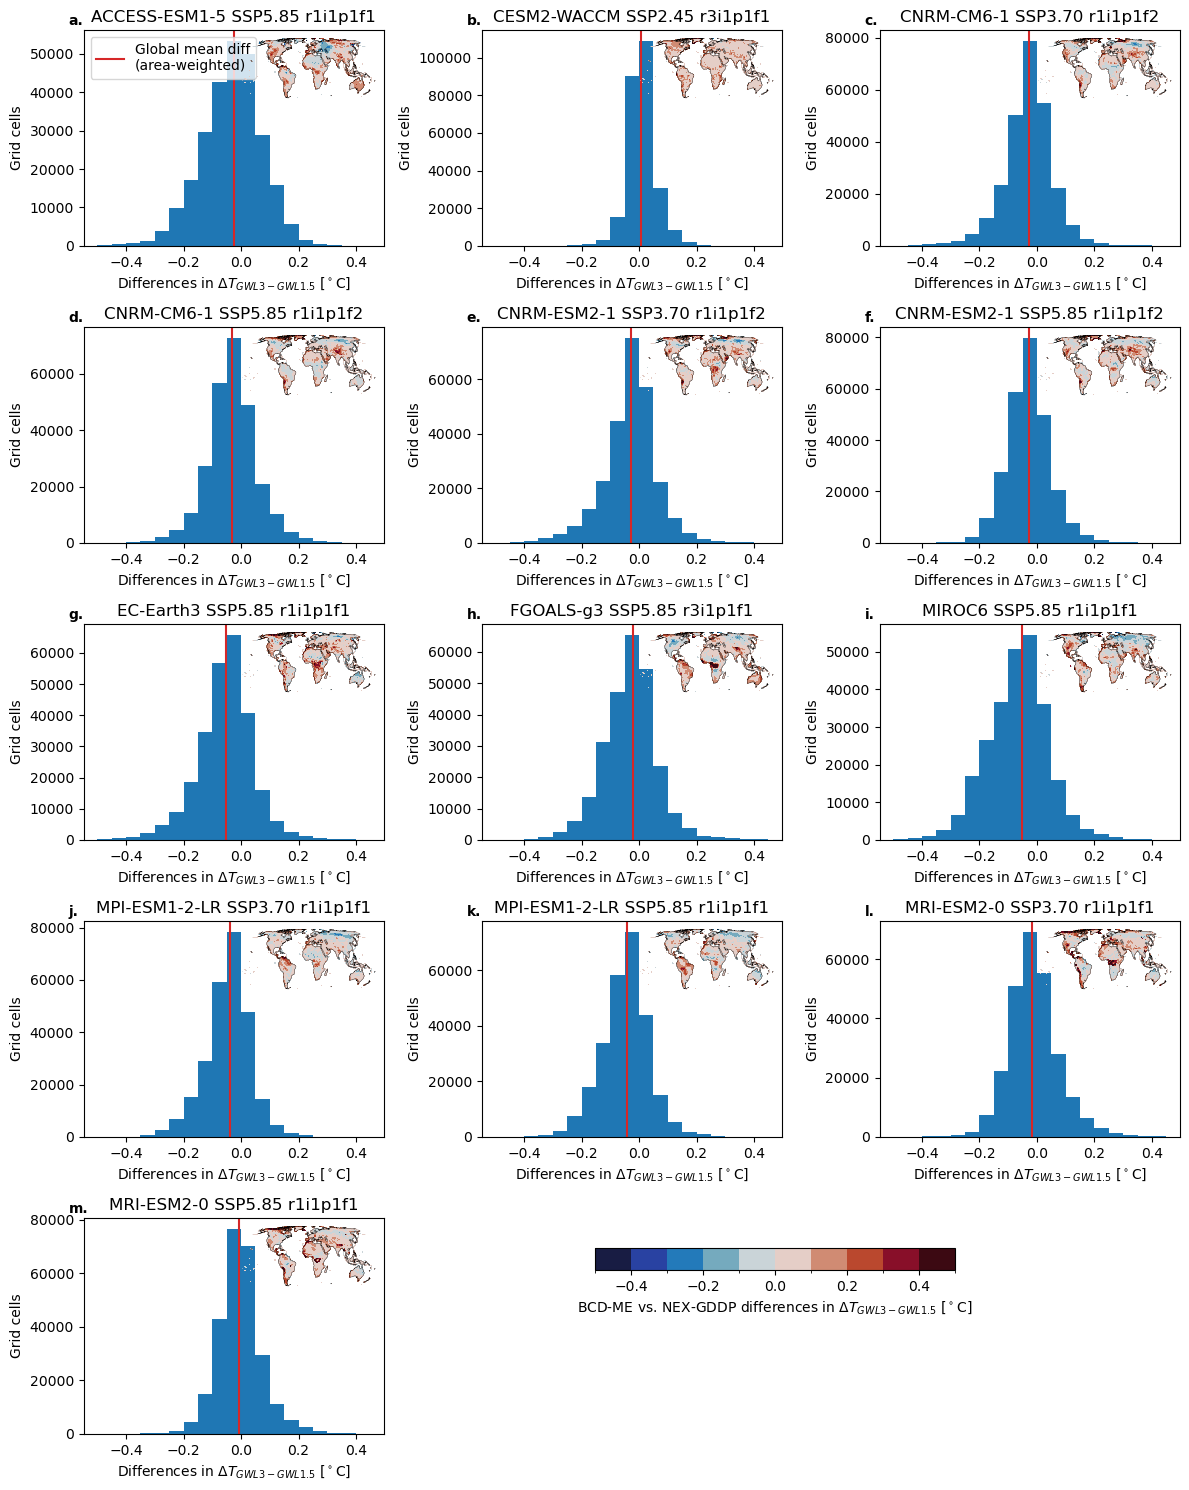

In [30]:
output_fn = f'{dir_list['aux']}diagnostics/bcd_vs_nex_diagnostic_histograms'
save_fig = True

ncol = 3

fig, axs = plt.subplots(
    nrows=(mean_diff.sizes['idv'] - 1) // ncol + 1,
    ncols=ncol,
    figsize=(12, 15),
    constrained_layout=False
)

cbar_params = {'vmin':-0.5,'vmax':0.5,
               'cmap':cmocean.cm.balance,'levels':11}
if 'levels' in cbar_params:
    levels = mpl.ticker.MaxNLocator(nbins=cbar_params['levels']).tick_values(cbar_params['vmin'],cbar_params['vmax'])
    norm = mpl.colors.BoundaryNorm(levels, ncolors=cbar_params['cmap'].N, clip=True)
else:
    norm = mpl.colors.Normalize(vmin=cbar_params['vmin'],vmax=cbar_params['vmax'])

# Histogram figures
for plt_idx,ax in enumerate(axs.flat):

    if plt_idx < mean_diff.sizes['idv']:
        plot_data = mean_diff.isel(idv = plt_idx).tasmean
        
        plot_data.plot.hist(bins = np.arange(-0.5,0.5,0.05),ax=ax)
        ax.axvline(area_mean(plot_data),color='tab:red',label='Global mean diff\n(area-weighted)')
        
        ax.set_xlabel(r'Differences in $\Delta T_{GWL3 - GWL1.5}$ [$^\circ$C]')
        ax.set_ylabel('Grid cells')
        exp_str = str(plot_data['experiment'].values)
        exp_str = exp_str.upper()
        exp_str = exp_str[0:4]+'.'+exp_str[4:None]
        ax.set_title(f'{plot_data['model'].values} {exp_str} {plot_data['run'].values}')
    
        if plt_idx == 0:
            ax.legend(loc='upper left')

        ax.annotate(string.ascii_lowercase[plt_idx]+'.',(-0.05,1.025),xycoords = 'axes fraction',
                    fontweight='bold')
    else:
        ax.set_axis_off()

plt.tight_layout()

# Map figures, now _after_ tight_layout(), to not mess it up
for plt_idx,ax in enumerate(axs.flat):
    if plt_idx < mean_diff.sizes['idv']:
        plot_data = mean_diff.isel(idv = plt_idx).tasmean

        ax_pos = ax.get_position()
        axh = ax_pos.y1-ax_pos.y0
        axw = ax_pos.x1-ax_pos.x0
        
        inset_pos = (ax_pos.x0 + 0.525*axw,
                     ax_pos.y0 + 0.6*axh,
                     axw*0.45,
                     axh*0.45)

        
        ax_in = fig.add_axes(inset_pos,projection=ccrs.EckertIV())
    
        # Plot
        plot_data.plot.contourf(transform=ccrs.PlateCarree(),**cbar_params,add_colorbar=False,
                       ax = ax_in, norm=norm)
    
        ax_in.coastlines(lw=0.25)
        ax_in.set_title('')
    
        # Remove map border
        #ax_in.outline_patch.set_visible(False)
        ax_in.axis('off')
        #ax_in.set_frame_on(False)

        

# With cbar_params syntax


clabel = r'BCD-ME vs. NEX-GDDP differences in $\Delta T_{GWL3 - GWL1.5}$ [$^\circ$C]'

# Vertical colorbar
cax = fig.add_axes([0.5, 0.15, 0.3, 0.015])
sm = plt.cm.ScalarMappable(cmap=cbar_params['cmap'],norm=norm)
plt.colorbar(sm,cax=cax,label=clabel,orientation='horizontal')

if save_fig:
    utility_print(output_fn)

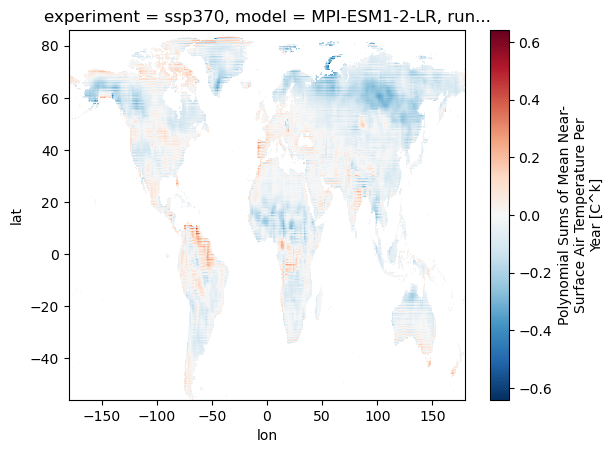

In [25]:
plot_data.plot()

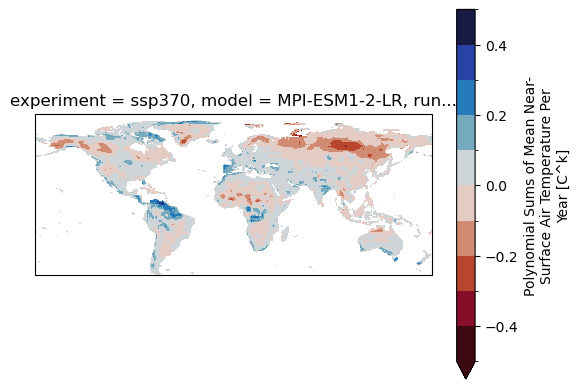

In [29]:
ax = plt.subplot(projection=ccrs.PlateCarree())
plot_data.plot.contourf(transform=ccrs.PlateCarree(),**cbar_params,add_colorbar=True,
                       ax = ax,norm=norm)

In [23]:
norm.vmax

0.5